# Snowflake Machine Learning

Pepsicola Demo



In [2]:
!pwd

/Users/knadadur/Documents/PepsiCola_Pytorch-main/notebook


In [1]:
#imports

from IPython.display import display, HTML, Image , Markdown
from snowflake.snowpark.session import Session
import time
import torch
import snowflake.snowpark.types as T
import snowflake.snowpark.functions as F
import os ,configparser ,json ,logging
import pandas as pd
from matplotlib import pyplot as plt
from snowflake.snowpark.functions import udf
from snowflake.snowpark.functions import lit 

import cachetools as ct
# Import the commonly defined utility scripts using
# dynamic path include
import sys
# The preprosessing module
sys.path.append('../')
sys.path.append('../lutils')
import sflk_base as L

display(Markdown("### Initialization"))
logging.basicConfig(stream=sys.stdout, level=logging.ERROR)

# Source various helper functions
%run ./scripts/notebook_helpers.py

# Define the project home directory, this is used for locating the config.ini file
PROJECT_HOME_DIR = '../'
config = L.get_config(PROJECT_HOME_DIR)
session = L.connect_to_snowflake(PROJECT_HOME_DIR)

if(session == None):
   raise Exception(f'Unable to connect to snowflake. Validate connection information ')

session.use_role(f'''{config['APP_DB']['role']}''')
session.use_schema(f'''{config['APP_DB']['database']}.{config['APP_DB']['schema']}''')
session.use_warehouse(f'''{config['SNOW_CONN']['warehouse']}''')

df1 = session.sql('select current_user() ,current_role() ,current_database() ,current_schema(), current_warehouse();').to_pandas()
display(df1)

### Initialization

,CURRENT_USER(),CURRENT_ROLE(),CURRENT_DATABASE(),CURRENT_SCHEMA(),CURRENT_WAREHOUSE()
0,KNADADUR,ACCOUNTADMIN,PEPSI,PUBLIC,HMWH


In [2]:
#load csv file into snowflake database
# data=pd.read_csv('../data/mam_data_snowpark_poc_small.csv')
data=pd.read_csv('../data/mam_data_snowpark_poc_big.csv')
session.create_dataframe(data).write.save_as_table(table_name='pepsibig', mode='overwrite')

In [4]:
#Create staging area called ML_MODEL to store ML Models

session.sql('CREATE OR REPLACE STAGE ML_MODEL').collect()

[Row(status='Stage area ML_MODEL successfully created.')]

In [5]:
session.sql('LIST @ML_MODEL').collect()

[]

In [1]:
session.close()

NameError: name 'session' is not defined

---
## 1. Preview Data and EDA

In [5]:
#Read data from Snowflake database and turn it into pandas dataframe

ad_df=session.table("pepsibig")
df=ad_df.to_pandas()

In [6]:
#Get basic information on data

display(Markdown("#### Summary Statistics"))
display(df.describe())
# missing value check
display(Markdown("#### Missing value check"))
display(df.isna().sum())
display(Markdown("There are no missing values, so there is no need to drop or impute missing data."))

#### Summary Statistics

,amazon_id,order_revenue,rep_oos,mean_rep_oos_7d,average_sales_price,mean_average_sales_price_7d,online_units,mean_online_units_7d,best_deal,lightning_deal,...,discount_price,discount_percentage,search_spend,business_unit,sub_business_unit,pepsi_brand,category,sub_category,min_qty,min_qty_enabled
count,120000.000000,120000.000000,120000.0,120000.0,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,...,120000.0,120000.0,120000.000000,120000.0,120000.000000,120000.000000,120000.000000,120000.000000,120000.0,120000.0
mean,0.635725,1096.583508,0.0,0.0,10.818746,10.203479,40.795694,28.929778,1.266059,17.781458,...,0.0,0.0,119.368055,0.0,4.248533,49.255283,8.915108,15.792775,0.0,0.0
std,0.481228,1739.083408,0.0,0.0,11.212320,10.943555,45.585061,39.625419,14.273131,227.550732,...,0.0,0.0,246.305770,0.0,0.968627,37.078249,5.309460,8.071835,0.0,0.0
min,0.000000,0.000000,0.0,0.0,0.500000,0.000000,-11.666964,-11.194459,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,3.000000,21.000000,2.000000,5.000000,0.0,0.0
25%,0.000000,0.000000,0.0,0.0,1.290000,0.533862,1.278354,0.135010,0.000000,1.231374,...,0.0,0.0,2.388436,0.0,3.000000,21.000000,2.000000,5.000000,0.0,0.0
50%,1.000000,47.070000,0.0,0.0,2.200000,2.047895,26.907185,14.865625,0.000000,3.920274,...,0.0,0.0,5.844342,0.0,5.000000,21.000000,13.000000,22.000000,0.0,0.0
75%,1.000000,1694.320000,0.0,0.0,24.010000,23.074672,75.585708,52.061969,0.116774,6.559220,...,0.0,0.0,124.893587,0.0,5.000000,98.000000,13.000000,22.000000,0.0,0.0
max,1.000000,8769.530000,0.0,0.0,28.120000,25.966667,339.524512,311.812858,445.489840,5951.232000,...,0.0,0.0,1870.610000,0.0,5.000000,99.000000,13.000000,22.000000,0.0,0.0


#### Missing value check

amazon_id                      0
ordered_date                   0
order_revenue                  0
rep_oos                        0
mean_rep_oos_7d                0
average_sales_price            0
mean_average_sales_price_7d    0
sales_not_exist                0
online_units                   0
mean_online_units_7d           0
best_deal                      0
lightning_deal                 0
price_discount                 0
promo_code                     0
discount_price                 0
discount_percentage            0
search_spend                   0
business_unit                  0
sub_business_unit              0
pepsi_brand                    0
category                       0
sub_category                   0
min_qty                        0
min_qty_enabled                0
dtype: int64

There are no missing values, so there is no need to drop or impute missing data.

In [7]:
df.shape

(120000, 24)

In [8]:
# determine feature types. numeric, categorical, binary feature.

display(Markdown("#### determine feature types: numeric, categorical, binary"))
display(df.nunique())

#### determine feature types: numeric, categorical, binary

amazon_id                           2
ordered_date                     1371
order_revenue                   53424
rep_oos                             1
mean_rep_oos_7d                     1
average_sales_price              1090
mean_average_sales_price_7d     99508
sales_not_exist                     3
online_units                   119935
mean_online_units_7d           119941
best_deal                       47285
lightning_deal                 100226
price_discount                      1
promo_code                      68916
discount_price                      1
discount_percentage                 1
search_spend                   106108
business_unit                       1
sub_business_unit                   2
pepsi_brand                        10
category                            3
sub_category                        4
min_qty                             1
min_qty_enabled                     1
dtype: int64

In [23]:
# !pip install pytorch_forecasting
# !pip install  lightning
# !pip install  lightning_utilities
# !pip install  fastapi
# !pip install  starlette
# !pip install  pydantic
# !pip install  deepdiff
# !pip install  ordered_set
# !pip install  lightning_cloud
# !pip install  uvicorn
# !pip install  websocket
# !pip install websockets==8.1
# !pip install  pytorch_optimizer
# !pip install  optuna
# !pip install  cmaes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 1.6 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 11.0.2
    Uninstalling websockets-11.0.2:
      Successfully uninstalled websockets-11.0.2


---
## 2. TFT Training Sproc 
### Sproc Packages and Imports

In [2]:
# imports and packages needed for pytorch forecasting to work

packages = ['snowflake-snowpark-python',
            'pytorch', 'joblib', 'tqdm',
            'colorlog', 'scikit-learn',
            'anyio', 'websockets', 'click',
            'fsspec', 'bs4', 'croniter',
            'torchmetrics', 'matplotlib',
            'sqlalchemy', 'statsmodels',
            'tensorboard', 'pytorch-lightning', 'rich'
           ]

imports = ['./snowflake_data_loader.py']
import pytorch_forecasting
imports.append(pytorch_forecasting.__path__[0])
import lightning
imports.append(lightning.__path__[0])
import lightning_utilities
imports.append(lightning_utilities.__path__[0])
import fastapi
imports.append(fastapi.__path__[0])
import starlette
imports.append(starlette.__path__[0])
import pydantic
imports.append(pydantic.__path__[0])
import deepdiff
imports.append(deepdiff.__path__[0])
import ordered_set
imports.append(ordered_set.__path__[0])
import lightning_cloud
imports.append(lightning_cloud.__path__[0])
import uvicorn
imports.append(uvicorn.__path__[0])
import websocket
imports.append(websocket.__path__[0])
import pytorch_optimizer
imports.append(pytorch_optimizer.__path__[0])
import optuna
imports.append(optuna.__path__[0])
import cmaes
imports.append(cmaes.__path__[0])

In [7]:
imports

['./snowflake_data_loader.py',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/pytorch_forecasting',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/lightning',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/lightning_utilities',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/fastapi',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/starlette',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/pydantic',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/deepdiff',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/ordered_set',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/lightning_cloud',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpark/lib/python3.8/site-packages/uvicorn',
 '/Users/knadadur/miniconda3/envs/pepsicosnowpa

### Sproc Definition and Registration 

In [3]:
def sproc_tft_model(session: Session, table_name: str, train_cfg: dict) -> T.Variant:
    from snowflake_data_loader import snowflakeDataLoader
    import lightning.pytorch as pl
    from pytorch_forecasting.metrics import MAE, MAPE, RMSE, SMAPE, QuantileLoss
    from pytorch_forecasting import TemporalFusionTransformer
    from lightning.pytorch.callbacks import (
        EarlyStopping,
        LearningRateMonitor,
        ModelCheckpoint,
    )
    import os
    torch.set_num_threads(os.cpu_count())
    
    # load data
    data = session.table(table_name).to_pandas()
    
    # create pytorch dataloader
    snowflake = snowflakeDataLoader(
        data = data, # this is currently a pandas DF
        min_dates = train_cfg['data_loader']['min_dates'],
        top_k = train_cfg['data_loader']['top_k']
    )
    snowflake(
        min_prediction_length = train_cfg['data_loader']['min_prediction_length'],
        max_prediction_length = train_cfg['data_loader']['max_prediction_length'],
        min_encoder_length = train_cfg['data_loader']['min_encoder_length'],
        max_encoder_length = train_cfg['data_loader']['max_encoder_length'],
        batch_size = train_cfg['data_loader']['batch_size'],
        num_workers = train_cfg['data_loader']['num_workers']
    )
    
    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
    lr_logger = LearningRateMonitor()
    run_id = str(time.time()).replace(".", "")
    dir = '/tmp'
    logger = pl.loggers.TensorBoardLogger(save_dir=f"{dir}/logs")
    checkpoint = ModelCheckpoint(
        dirpath=dir, filename="{epoch}-{val_loss:.2f}-{other_metric:.2f}",
        monitor="val_loss"
    )

    trainer = pl.Trainer(
        max_epochs=train_cfg['trainer']['max_epochs'],
        gradient_clip_val=train_cfg['hyper_params']['gradient_clip_val'],
        callbacks=[early_stop_callback, lr_logger],
        logger=logger,
        default_root_dir=f"{dir}/data/",
        limit_train_batches=train_cfg['trainer']['limit_train_batches'],
        limit_test_batches=train_cfg['trainer']['limit_train_batches'],
##        benchmark=True,
    )

    tft = TemporalFusionTransformer.from_dataset(
        snowflake.dataset,
        learning_rate=train_cfg['hyper_params']['learning_rate'],
        hidden_size=train_cfg['hyper_params']['hidden_size'],
        attention_head_size=train_cfg['hyper_params']['attention_head_size'],
        dropout=train_cfg['hyper_params']['dropout'],
        hidden_continuous_size=train_cfg['hyper_params']['hidden_continuous_size'],
        output_size=7,
        optimizer="sgd",
        loss=QuantileLoss(),
        logging_metrics=[SMAPE(), MAPE(), RMSE(), MAE()],
        reduce_on_plateau_patience=4,
    )

    start = time.time()
    trainer.fit(
        tft,
        snowflake.train_dataloader,
        snowflake.val_dataloader,

    )
    training_time = time.time()-start
    
    if train_cfg['save_model']:
        ckpt_path = trainer.checkpoint_callback.best_model_path
        ckpt_path_rename = '/'.join(ckpt_path.split('/')[:-1]+[train_cfg['save_model']])
        
        import os  
        os.rename(ckpt_path, ckpt_path_rename)
        stage_location = train_cfg['stage_location']
        session.file.put(ckpt_path_rename, f'{stage_location}/pepsi', auto_compress=False, overwrite=True)
        
    output = {k: v.item() for k, v in trainer.callback_metrics.items()}
    output['training_time'] = training_time
    return output

# Registering the function as a Stored Procedure
sproc_tft_model = session.sproc.register(func=sproc_tft_model, 
                                                      name='sproc_tft_model1', 
                                                      is_permanent=True, 
                                                      replace=True,
                                                      stage_location='ML_MODEL', 
                                                      packages=packages, 
                                                      imports=imports)

In [4]:
session.sql('LIST @ML_MODEL').collect()

[Row(name='ml_model/020953695959a0487ec951379af520e730e883b3c49f05c98195ada52ad72b08/pydantic.zip', size=2595200, md5='6a813109fa1a71cb22f7d4651530e451', last_modified='Wed, 4 Oct 2023 05:13:58 GMT'),
 Row(name='ml_model/021db898feeaf88891084b556061b5b16718cacc492cc10e50c22ef5b6389234/lightning.zip', size=1823456, md5='f1a354e0ed78f19aace050b005b87ebc', last_modified='Wed, 4 Oct 2023 05:13:52 GMT'),
 Row(name='ml_model/0282eb7e81d5d53758137c50c632793fe57d5bf9689f86d2b48a60cdeb7a54d3/ordered_set.zip', size=4704, md5='0c1643c62e9d2a00d9f1beaf1e7bb6ad', last_modified='Wed, 4 Oct 2023 05:13:59 GMT'),
 Row(name='ml_model/051a93fe05aac6c9b7cdd07d90d4e44e353f5d8b67e9101e8d367ce3b96890dc/pytorch_forecasting.zip', size=134784, md5='4cb6cbf9f89b3db30f5ed78bd94669b0', last_modified='Wed, 4 Oct 2023 05:13:49 GMT'),
 Row(name='ml_model/2cca2719936f874af6d1dd399d84adf2dbf9108b937ac96a6a761e54e8ca9c15/starlette.zip', size=58816, md5='a3de83e397eddab3a6ae059a3e783c6e', last_modified='Wed, 4 Oct 2023 0

### After the change on product side, testing the code

In [10]:
%%time
train_cfg = {
    'save_model': False,
    'stage_location': 'ML_MODEL',
    'trainer': {
        'max_epochs': 1,
        'limit_train_batches': 200,
        'limit_val_batches': 500,
    },
    'data_loader': {
        'min_dates': 15,
        'top_k': 1000,
        'min_prediction_length': 3,
        'max_prediction_length': 10,
        'min_encoder_length': 4,
        'max_encoder_length': 256,
        'batch_size': 64,
        'num_workers': 0
    },
    'hyper_params': {
        'gradient_clip_val': 0.5,
        'learning_rate': 0.005,
        'hidden_size': 78,
        'attention_head_size': 12,
        'dropout': 0.35,
        'hidden_continuous_size': 9,
    },
}

json.dumps(train_cfg)
output = sproc_tft_model('pepsi', train_cfg)

CPU times: user 357 ms, sys: 266 ms, total: 623 ms
Wall time: 24min 3s


### Before the change on product side, testing the code

In [6]:
%%time
train_cfg = {
    'save_model': False,
    'stage_location': 'ML_MODEL',
    'trainer': {
        'max_epochs': 1,
        'limit_train_batches': 200,
        'limit_val_batches': 500,
    },
    'data_loader': {
        'min_dates': 15,
        'top_k': 1000,
        'min_prediction_length': 3,
        'max_prediction_length': 10,
        'min_encoder_length': 4,
        'max_encoder_length': 256,
        'batch_size': 64,
        'num_workers': 0
    },
    'hyper_params': {
        'gradient_clip_val': 0.5,
        'learning_rate': 0.005,
        'hidden_size': 78,
        'attention_head_size': 12,
        'dropout': 0.35,
        'hidden_continuous_size': 9,
    },
}

json.dumps(train_cfg)
output = sproc_tft_model('pepsi', train_cfg)

CPU times: user 402 ms, sys: 86.7 ms, total: 489 ms
Wall time: 24min 9s


In [ ]:
        # max_epochs=100,
        # weights_summary="top",
        # gradient_clip_val=0.5,
        # gpus=1,
        # callbacks=[early_stop_callback, lr_logger],
        # logger=logger,
        # default_root_dir=f"{dir}/data/",
        # #limit_train_batches=200,
        # #limit_val_batches=500,
        # auto_lr_find=True,


In [8]:
output

'{\n  "train_loss": 527.0557861328125,\n  "train_loss_epoch": 527.0557861328125,\n  "train_loss_step": 426.99267578125,\n  "training_time": 253.20520401000977,\n  "val_MAE": 1509.4652099609375,\n  "val_MAPE": 63457153024,\n  "val_RMSE": 2342.146240234375,\n  "val_SMAPE": 1.4523849487304688,\n  "val_loss": 688.3558349609375\n}'

In [23]:
# 10 minibatches
# 4:08 seconds to execute "training" code
# 5.6x slower than local 
# removing startup, 10.3x slower
# 4:19 for total sproc call, 11 seconds of extra overhead 

# 1 epoch
# 20:45 to execute "training" code
# 13.5x slower than local
# removing startup, ~20x slower

In [46]:
x = (1245-248)/(51-10)
x

24.317073170731707

In [49]:
10*x

243.17073170731706

#### Sproc vs LOCAL Training
1. 10 minibatches training time 
- LOCAL: 0:24 
- SPROC: 4:08 

2. 1 epoch (51 minibatches)
- LOCAL: 1:10
- SPROC: 20:40 

3. Startup times
- LOCAL 20-30 seconds
- SPROC 17 seconds

**sproc takes 10-17x longer per minibatch/epoch compared to training on a macbook** for a single model. 17x is the better estimate as due slow startup of first few batches on local and full epoch times are what should be used for comparison. 

#### Final model estimates
100 epochs
- LOCAL: 2 Hours
- SPROC: 34 Hours

#### HPO estimate
100 trials of 20 epochs
- LOCAL: 39 Hours
- SPROC: 27.5 Days



---
## 3. Optuna HPO with TFT Sproc

In [9]:
import optuna

def objective(trial, train_cfg):
    # get hyper params
    train_cfg['hyper_params']['gradient_clip_val'] = trial.suggest_float("gradient_clip_val", 0.01, 1.0, log=False)
    train_cfg['hyper_params']['learning_rate'] = trial.suggest_float("learning_rate", 0.001, 0.5, log=True)
    train_cfg['hyper_params']['dropout'] = trial.suggest_float("dropout", 0.1, 0.7, log=False)
    train_cfg['hyper_params']['hidden_size'] = trial.suggest_int("hidden_size", 4, 256, log=True)
    train_cfg['hyper_params']['attention_head_size'] = trial.suggest_int("attention_head_size", 1, 16, log=False)
    train_cfg['hyper_params']['hidden_continuous_size'] = trial.suggest_int("hidden_continuous_size", 4, 256, log=True)
    # train tft model with selected hyper params
    score = eval(sproc_tft_model('pepsi', train_cfg))['val_loss']    
    trial.set_user_attr(key="best_booster", value=train_cfg['hyper_params'])
    
    return score 

def callback(study, trial):
    if study.best_trial.number == trial.number:
        study.set_user_attr(key="best_booster", value=trial.user_attrs["best_booster"])
          
train_cfg = {
    'save_model': False,
    'stage_location': 'ML_MODEL',
    'trainer': {
        'max_epochs': 1,
        'limit_train_batches': 5,
        'limit_val_batches': 5,
    },
    'data_loader': {
        'min_dates': 15,
        'top_k': 1000,
        'min_prediction_length': 3,
        'max_prediction_length': 10,
        'min_encoder_length': 4,
        'max_encoder_length': 256,
        'batch_size': 64,
        'num_workers': 0
    },
    'hyper_params': {
        'gradient_clip_val': 0.5,
        'learning_rate': 0.005,
        'hidden_size': 78,
        'attention_head_size': 12,
        'dropout': 0.35,
        'hidden_continuous_size': 9,
    },
}
       
retrain_best = True
n_trials = 5

study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, train_cfg), n_trials=n_trials, callbacks=[callback])

best_hyperparams=study.user_attrs["best_booster"]

if retrain_best:
    print('Retraining Model with best Hyper Paramaters')
    train_cfg['save_model'] = 'tft_test'
    train_cfg['hyper_params'] = best_hyperparams
    # train_cfg['trainer']['limit_train_batches'] = None
    # train_cfg['trainer']['limit_val_batches'] = None
    # train_cfg['trainer']['max_epochs'] = 100
    output = sproc_tft_model('pepsi', train_cfg)

[I 2023-05-24 07:49:08,110] A new study created in memory with name: no-name-2677d3a0-94d7-4e80-9775-7cbed89ee5b3
[I 2023-05-24 07:53:15,409] Trial 0 finished with value: 560.1311645507812 and parameters: {'gradient_clip_val': 0.7687422872826782, 'learning_rate': 0.09556988855749736, 'dropout': 0.5081786052403969, 'hidden_size': 208, 'attention_head_size': 15, 'hidden_continuous_size': 7}. Best is trial 0 with value: 560.1311645507812.
[I 2023-05-24 07:54:05,230] Trial 1 finished with value: 1066.868896484375 and parameters: {'gradient_clip_val': 0.4320986485570454, 'learning_rate': 0.17184142114773215, 'dropout': 0.29327171963437393, 'hidden_size': 6, 'attention_head_size': 2, 'hidden_continuous_size': 69}. Best is trial 0 with value: 560.1311645507812.
[I 2023-05-24 07:58:02,111] Trial 2 finished with value: 965.5563354492188 and parameters: {'gradient_clip_val': 0.6655266267406073, 'learning_rate': 0.19496368205356315, 'dropout': 0.1508042690706473, 'hidden_size': 162, 'attention_he

Retraining Model with best Hyper Paramaters


In [10]:
session.sql('LIST @ML_MODEL').collect()

[Row(name='ml_model/020953695959a0487ec951379af520e730e883b3c49f05c98195ada52ad72b08/pydantic.zip', size=2595200, md5='ea20d2315ca3260f10e0b85b501d5058', last_modified='Wed, 24 May 2023 14:39:31 GMT'),
 Row(name='ml_model/021db898feeaf88891084b556061b5b16718cacc492cc10e50c22ef5b6389234/lightning.zip', size=1823456, md5='04e2dfb05028b742d2be80ae74686abb', last_modified='Wed, 24 May 2023 14:38:59 GMT'),
 Row(name='ml_model/0282eb7e81d5d53758137c50c632793fe57d5bf9689f86d2b48a60cdeb7a54d3/ordered_set.zip', size=4704, md5='1fd774c7df21728d70a7c4ec34b63c46', last_modified='Wed, 24 May 2023 14:39:35 GMT'),
 Row(name='ml_model/051a93fe05aac6c9b7cdd07d90d4e44e353f5d8b67e9101e8d367ce3b96890dc/pytorch_forecasting.zip', size=134784, md5='8623f66a9787a04576beb46d714777b2', last_modified='Wed, 24 May 2023 14:38:33 GMT'),
 Row(name='ml_model/2cca2719936f874af6d1dd399d84adf2dbf9108b937ac96a6a761e54e8ca9c15/starlette.zip', size=58816, md5='ff1366c89980f297bbf74c93fc58f933', last_modified='Wed, 24 May 2

In [11]:
eval(output)

{'train_loss': 469.01318359375,
 'train_loss_epoch': 469.01318359375,
 'train_loss_step': 380.99957275390625,
 'training_time': 35.956846952438354,
 'val_MAE': 360.6966552734375,
 'val_MAPE': 17510881280,
 'val_RMSE': 548.4899291992188,
 'val_SMAPE': 1.4010547399520874,
 'val_loss': 792.1360473632812}

In [ ]:
# get predictions
    dir = '/tmp'
    trainer_kwargs = {
        'logger': pl.loggers.TensorBoardLogger(save_dir=f"{dir}/logs"),
        'default_root_dir': f"{dir}/data/",
    }

---
## 4. SPROC Forecaster
### SPROC Definition and Registration 

In [15]:
def sproc_tft_predictor(session: Session, table_name: str, train_cfg: dict) -> T.Variant:
    from snowflake_data_loader import snowflakeDataLoader
    from pytorch_forecasting import TemporalFusionTransformer
    import lightning.pytorch as pl
    import os
    import sys
    
    
    # load data
    data = session.table(table_name).to_pandas()
    
    # use snowflake data loader for preprocessing
    snowflake = snowflakeDataLoader(
        data = data,
        min_dates = train_cfg['data_loader']['min_dates'],
        top_k = train_cfg['data_loader']['top_k']
    )
    snowflake(
        min_prediction_length = train_cfg['data_loader']['min_prediction_length'],
        max_prediction_length = train_cfg['data_loader']['max_prediction_length'],
        min_encoder_length = train_cfg['data_loader']['min_encoder_length'],
        max_encoder_length = train_cfg['data_loader']['max_encoder_length'],
        batch_size = train_cfg['data_loader']['batch_size'],
        num_workers = train_cfg['data_loader']['num_workers']
    )
    
    # get latest period for future prediction
    max_prediction_length = train_cfg['data_loader']['max_prediction_length']
    max_encoder_length = train_cfg['data_loader']['max_encoder_length']*2 # outputting 2 ts so multiply by 2
    time_df = snowflake.dataframe
    time_df = time_df.sort_values('time_idx').reset_index(drop=True)
    encoder_data = time_df[-min(max_encoder_length, len(time_df)):]
    last_data = time_df[lambda x: x.time_idx == x.time_idx.max()]
    decoder_data = pd.concat(
        [last_data.assign(time_idx=lambda x: x.time_idx + i+1) for i in range(max_prediction_length)],
        ignore_index=True,
    )
    new_prediction_data = pd.concat([encoder_data, decoder_data], ignore_index=True)
    
    # load model
    IMPORT_DIRECTORY_NAME = "snowflake_import_directory"
    import_dir = sys._xoptions[IMPORT_DIRECTORY_NAME]
    tft_model = TemporalFusionTransformer.load_from_checkpoint(import_dir+train_cfg['save_model'])
    
    # get predictions
    
    # trainer_kwargs = {
    #     'logger': pl.loggers.TensorBoardLogger(save_dir=f"{dir}/logs"),
    #     'default_root_dir': f"{dir}/data/",
    # }

# get predictions
    dir = '/tmp'
    trainer_kwargs = {
        'logger': pl.loggers.TensorBoardLogger(save_dir=f"{dir}/logs"),
        'default_root_dir': f"{dir}/data/",
    }
    
    output_new = tft_model.predict(new_prediction_data, mode="raw", return_x=True, 
                                   trainer_kwargs=trainer_kwargs)
    new_raw_predictions, new_x = output_new.output, output_new.x
        
    def tensor2json(t):
        return {
            'data': list(t.flatten().numpy().astype(str)),
            'shape': list(t.shape)
        }
    
    
    return tensor2json(new_raw_predictions.prediction)

# Registering the function as a Stored Procedure
sproc_tft_predictor = session.sproc.register(func=sproc_tft_predictor, 
                                          name='sproc_tft_predictor', 
                                          is_permanent=True, 
                                          replace=True,
                                          stage_location='ML_MODEL', 
                                          packages=packages, 
                                          # imports=imports+['@ML_MODEL/pepsi/tft_test'])
                                          imports=imports+['/Users/knadadur/Downloads/tft_test'])

### Prediction Testing

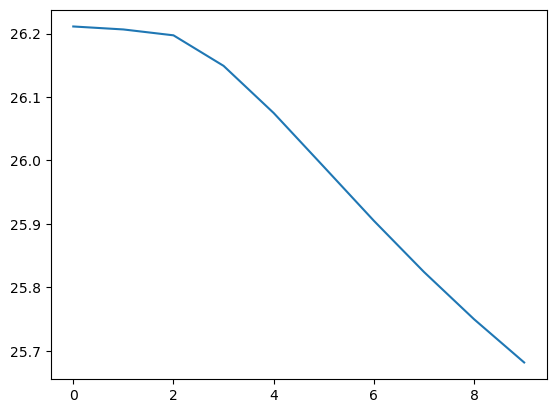

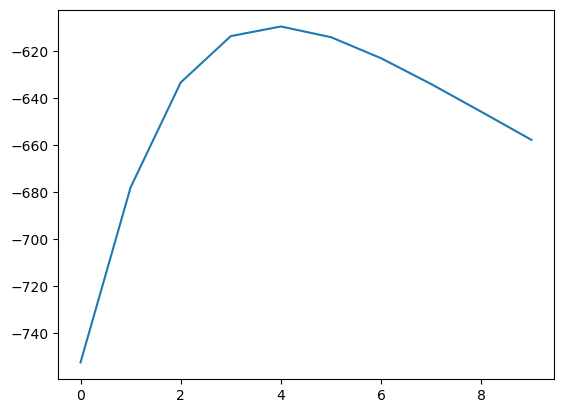

In [16]:
def json2tensor(j):
    j['data'] = [float(d) for d in j['data']]
    return torch.tensor(j['data']).reshape(j['shape'])

output = sproc_tft_predictor('pepsi', train_cfg)
output_tensor = json2tensor(eval(output))

# we are predicting two time series, additionally with have 7 
# quartiles so we use the middle quartile (index 3) as our prediction
plt.plot(output_tensor[0,:,3])
plt.show()
plt.plot(output_tensor[1,:,3])
plt.show()

In [ ]:
output_tensor.shape

--- 
## Closeout

    With that we are finished this section of the demo setup

In [ ]:
session.close()
print('Finished!!!')